In [18]:
import pyprind
import xgboost
import pandas as pd
import os
import sys
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer , TfidfTransformer, HashingVectorizer
import numpy as np
import re
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix
from nltk.stem.porter import PorterStemmer
from sklearn.decomposition import LatentDirichletAllocation
import joblib
import nltk
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

In [11]:
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt',
                    sep='\t',
                    usecols=columns)
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [12]:
df.iloc[:, :4].isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
dtype: int64

In [13]:
df.tail()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
2925,6,6,1003.0,Y,1003,142500
2926,5,5,864.0,Y,902,131000
2927,5,5,912.0,Y,970,132000
2928,5,5,1389.0,Y,1389,170000
2929,7,5,996.0,Y,2000,188000


In [14]:
df.shape

(2930, 6)

In [15]:
df['Central Air'] = df['Central Air'].map({"N": 0, "Y": 1})

I will deal with the Nan value by substitution using mode, you can drop the null value because our data is large relativly to our missing value. (which is just one value)

In [16]:
df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].mode().iloc[0])

In [17]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

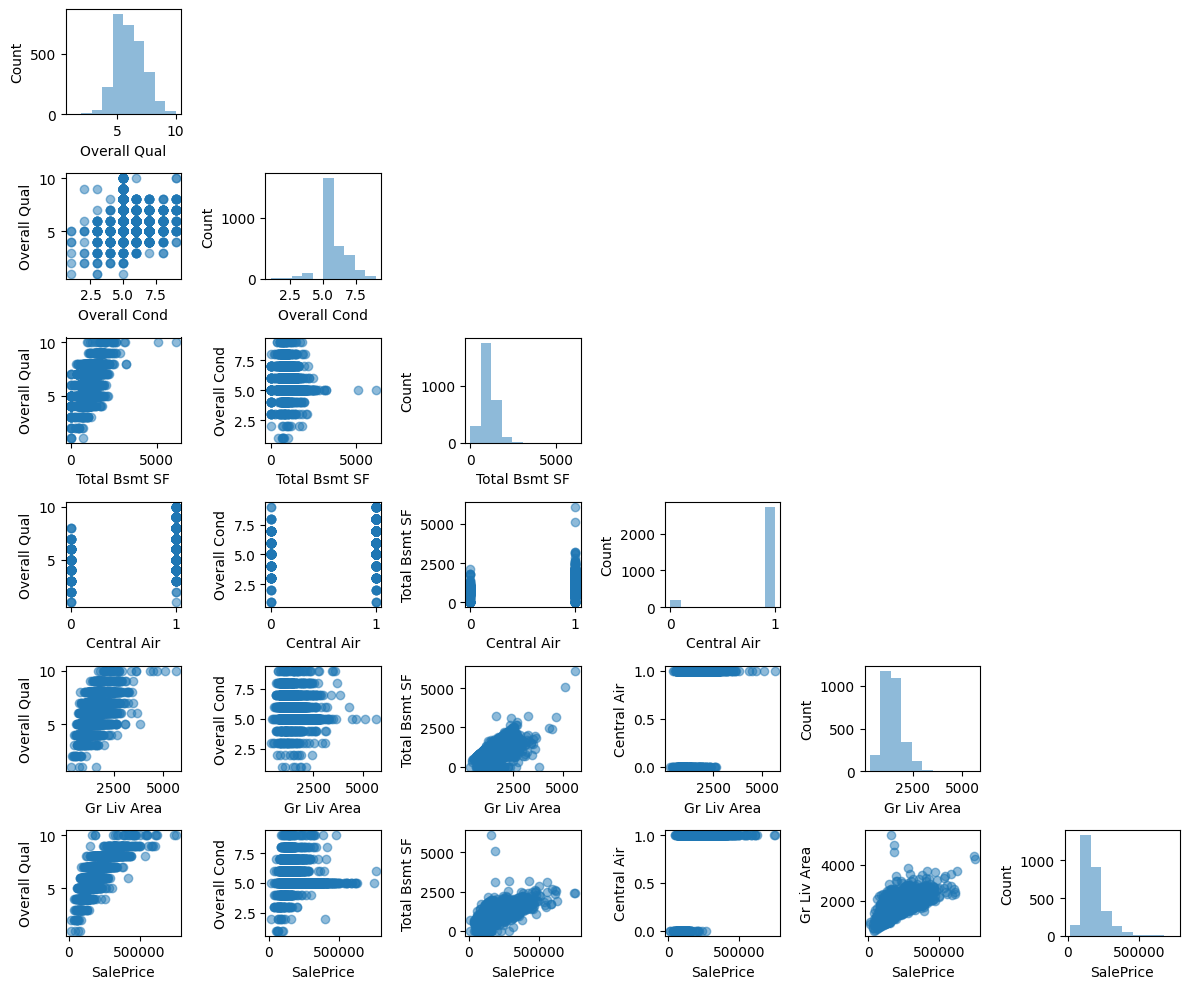

In [19]:
scatterplotmatrix(df.values, figsize=(12, 10), names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()